In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Load the dataset
data = pd.read_csv("/content/drive/MyDrive/DATASETS/cars_ds_final_2021.csv")


In [ ]:
# Data Preprocessing
data = data.drop(columns=["Index"])  # Drop irrelevant columns
data.fillna(method='ffill', inplace=True)  # Handle missing values

# Remove "Rs." prefix and commas from "Ex-Showroom_Price" column and convert to float
data['Ex-Showroom_Price'] = data['Ex-Showroom_Price'].str.replace('Rs. ', '').str.replace(',', '').astype(float)

# Remove "mm" suffix from "Height", "Length", and "Width" columns
data['Height'] = data['Height'].str.replace(' mm', '').astype(float)
data['Length'] = data['Length'].str.replace(' mm', '').astype(float)
data['Width'] = data['Width'].str.replace(' mm', '').astype(float)

# Encode categorical columns with Label Encoding
encoder = LabelEncoder()
columns_to_encode = ['Drivetrain', 'Emission_Norm', 'Cylinder_Configuration', 'Fuel_Type', 'Body_Type']
for col in columns_to_encode:
    data[col+'_encoded'] = encoder.fit_transform(data[col])

# Remove " cc" suffix from "Displacement" column and convert to float
data['Displacement'] = data['Displacement'].str.replace(' cc', '').astype(float)


<ipython-input-3-89e332a6be19>:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[col+'_encoded'] = encoder.fit_transform(data[col])
<ipython-input-3-89e332a6be19>:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[col+'_encoded'] = encoder.fit_transform(data[col])
<ipython-input-3-89e332a6be19>:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a

In [ ]:
print(data.head())

   Make      Model  Variant  Ex-Showroom_Price  Displacement  Cylinders  \
0  Tata  Nano Genx       Xt           292667.0         624.0        2.0   
1  Tata  Nano Genx       Xe           236447.0         624.0        2.0   
2  Tata  Nano Genx  Emax Xm           296661.0         624.0        2.0   
3  Tata  Nano Genx      Xta           334768.0         624.0        2.0   
4  Tata  Nano Genx       Xm           272223.0         624.0        2.0   

   Valves_Per_Cylinder              Drivetrain Cylinder_Configuration  \
0                  2.0  RWD (Rear Wheel Drive)                In-line   
1                  2.0  RWD (Rear Wheel Drive)                In-line   
2                  2.0  RWD (Rear Wheel Drive)                In-line   
3                  2.0  RWD (Rear Wheel Drive)                In-line   
4                  2.0  RWD (Rear Wheel Drive)                In-line   

  Emission_Norm  ... USB_Ports Heads-Up_Display Welcome_Lights Battery  \
0         BS IV  ...       NaN      

In [ ]:

# Define X variable with specified features
X = data[['Displacement', 'Cylinders', 'Valves_Per_Cylinder', 'Drivetrain_encoded',
          'Cylinder_Configuration_encoded', 'Emission_Norm_encoded', 'Fuel_Type_encoded', 'Height',
          'Length', 'Width', 'Body_Type_encoded']]

y = data['Ex-Showroom_Price']  # Define target variable

# Model Training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# User Input Handling
num_doors = int(input("Enter the number of doors (4 or 5): "))
fuel_type = input("Enter preferred fuel type (Petrol,Diesel,CNG,Hybrid,Electric,Cng+Petrol): ").capitalize()  # Capitalize input for consistency
price_range_low = float(input("Enter minimum price range: "))
price_range_high = float(input("Enter maximum price range: "))

# Filter data based on user preferences
filtered_data = data[(data['Doors'] == num_doors) &
                     (data['Fuel_Type'] == fuel_type) &
                     (data['Ex-Showroom_Price'] >= price_range_low) &
                     (data['Ex-Showroom_Price'] <= price_range_high)]

# Define X_pred variable with specified features for prediction
X_pred = filtered_data[['Displacement', 'Cylinders', 'Valves_Per_Cylinder', 'Drivetrain_encoded',
                        'Cylinder_Configuration_encoded', 'Emission_Norm_encoded', 'Fuel_Type_encoded', 'Height',
                        'Length', 'Width', 'Body_Type_encoded']]


# Prediction
if len(X_pred) > 0:
    predictions = model.predict(X_pred)

    # Display Results
    results = filtered_data.copy()
    results['Predicted_Price'] = predictions
    print(results)
else:
    print("No matching cars found based on the provided criteria.")


# Display Results
results = filtered_data.copy()
results['Predicted_Price'] = predictions
results


Enter the number of doors (4 or 5): 4
Enter preferred fuel type (Petrol,Diesel,CNG,Hybrid,Electric,Cng+Petrol): petrol
Enter minimum price range: 500000
Enter maximum price range: 800000
               Make           Model                   Variant  \
47          Hyundai          Santro                  Magna Mt   
49          Hyundai          Santro                 Magna Amt   
50          Hyundai          Santro                 Sportz Mt   
52          Hyundai          Santro                Sportz Amt   
53          Hyundai          Santro                   Asta Mt   
113         Hyundai     Xcent Prime                         T   
114         Hyundai     Xcent Prime                        T+   
119   Maruti Suzuki      Dzire Tour                       Lxi   
153   Maruti Suzuki           Dzire                       Lxi   
154   Maruti Suzuki           Dzire                       Vxi   
156   Maruti Suzuki           Dzire                       Zxi   
158   Maruti Suzuki           Dzi

,Make,Model,Variant,Ex-Showroom_Price,Displacement,Cylinders,Valves_Per_Cylinder,Drivetrain,Cylinder_Configuration,Emission_Norm,...,Heads-Up_Display,Welcome_Lights,Battery,Electric_Range,Drivetrain_encoded,Emission_Norm_encoded,Cylinder_Configuration_encoded,Fuel_Type_encoded,Body_Type_encoded,Predicted_Price
47,Hyundai,Santro,Magna Mt,503990.0,1086.0,4.0,4.0,FWD (Front Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,2,2,1,5,5,512845.752857
49,Hyundai,Santro,Magna Amt,530990.0,1086.0,4.0,4.0,FWD (Front Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,2,2,1,5,5,512845.752857
50,Hyundai,Santro,Sportz Mt,512990.0,1086.0,4.0,4.0,FWD (Front Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,2,2,1,5,5,512845.752857
52,Hyundai,Santro,Sportz Amt,570990.0,1086.0,4.0,4.0,FWD (Front Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,2,2,1,5,5,512845.752857
53,Hyundai,Santro,Asta Mt,556490.0,1086.0,4.0,4.0,FWD (Front Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,2,2,1,5,5,512845.752857
113,Hyundai,Xcent Prime,T,536859.0,1197.0,4.0,4.0,FWD (Front Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,2,2,1,5,11,686151.921961
114,Hyundai,Xcent Prime,T+,556130.0,1197.0,4.0,4.0,FWD (Front Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,2,2,1,5,11,686151.921961
119,Maruti Suzuki,Dzire Tour,Lxi,553423.0,1197.0,4.0,4.0,FWD (Front Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,2,2,1,5,11,594623.888429
153,Maruti Suzuki,Dzire,Lxi,582613.0,1197.0,4.0,4.0,FWD (Front Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,2,2,1,5,11,718520.734636
154,Maruti Suzuki,Dzire,Vxi,673112.0,1197.0,4.0,4.0,FWD (Front Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,2,2,1,5,11,718520.734636


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the testing set
y_pred = model.predict(X_test)

# Evaluate the model's performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Absolute Error: 959178.1300673274
Mean Squared Error: 15934203970661.377
R-squared: 0.8410295570387538


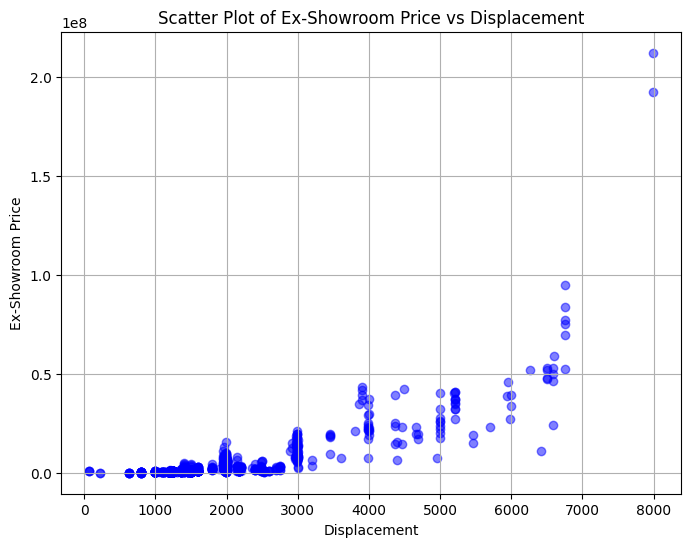

In [ ]:
import matplotlib.pyplot as plt

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(data['Displacement'], data['Ex-Showroom_Price'], color='blue', alpha=0.5)
plt.title('Scatter Plot of Ex-Showroom Price vs Displacement')
plt.xlabel('Displacement')
plt.ylabel('Ex-Showroom Price')
plt.grid(True)

# Show plot
plt.show()


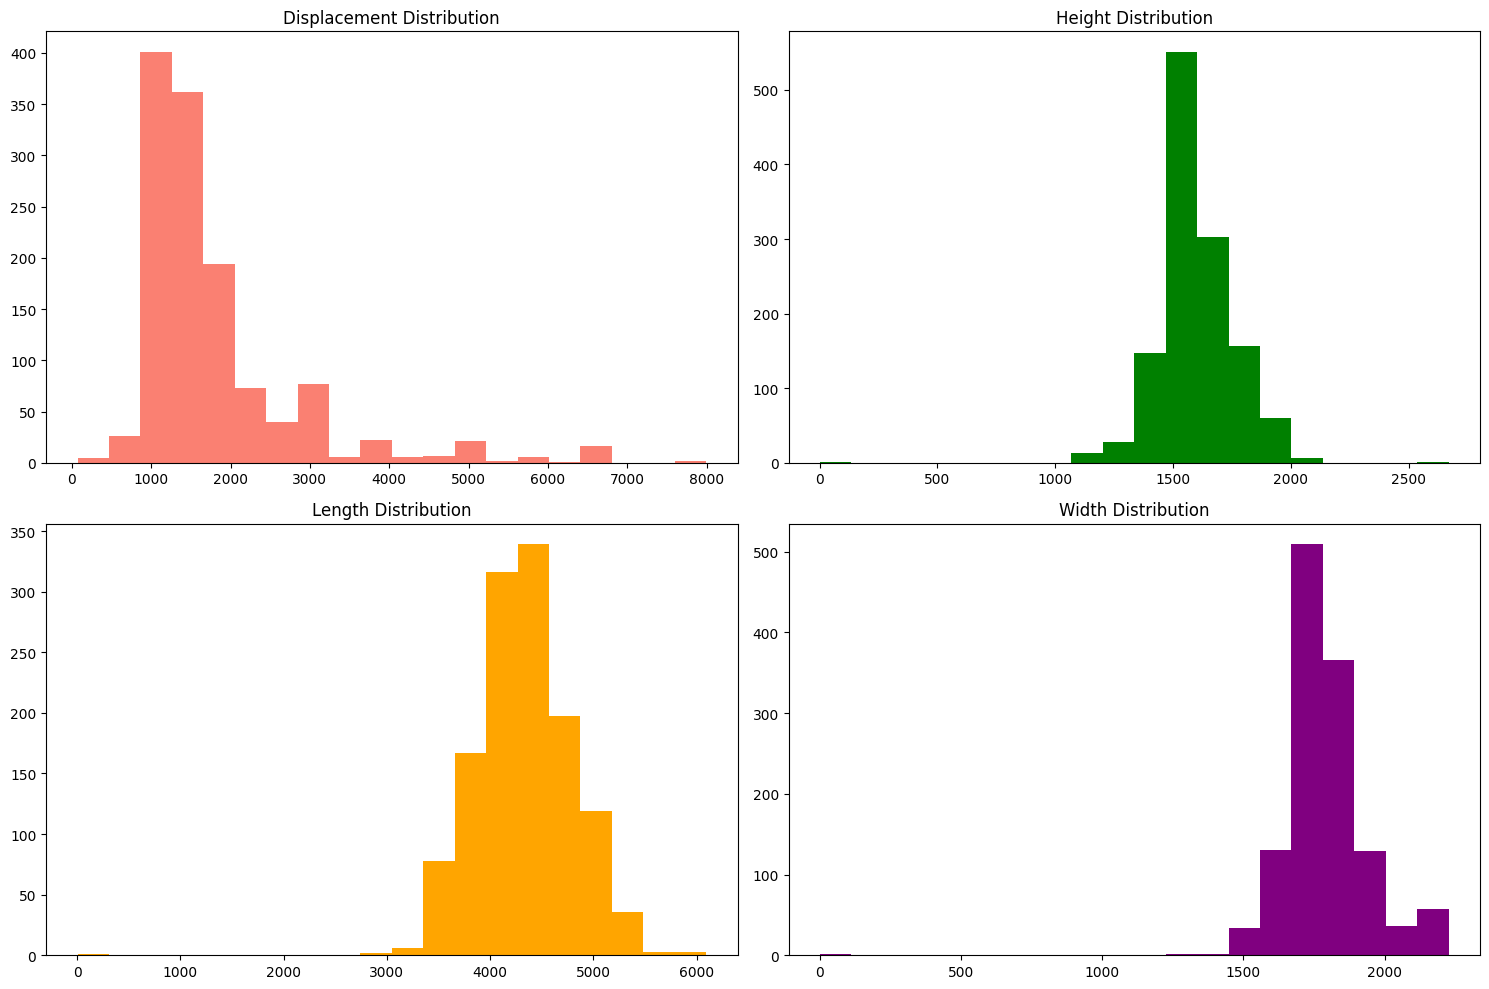

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Create subplots for each numerical variable
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

# Plot histograms for Displacement, Height, Length, and Width
axes[0, 0].hist(data['Displacement'], bins=20, color='salmon')
axes[0, 0].set_title('Displacement Distribution')

axes[0, 1].hist(data['Height'], bins=20, color='green')
axes[0, 1].set_title('Height Distribution')

axes[1, 0].hist(data['Length'], bins=20, color='orange')
axes[1, 0].set_title('Length Distribution')

axes[1, 1].hist(data['Width'], bins=20, color='purple')
axes[1, 1].set_title('Width Distribution')

plt.tight_layout()
plt.show()


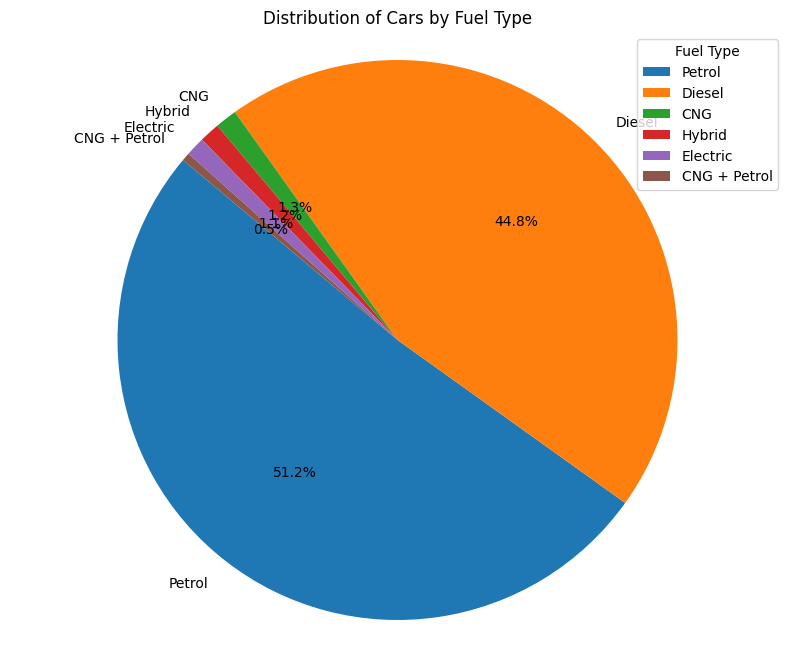

In [ ]:
import matplotlib.pyplot as plt

# Calculate the proportion of cars by Fuel Type
fuel_type_counts = data['Fuel_Type'].value_counts()

# Create a pie chart
plt.figure(figsize=(10, 8))
plt.pie(fuel_type_counts, labels=fuel_type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Cars by Fuel Type')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.legend(title='Fuel Type', loc='upper right')
plt.show()


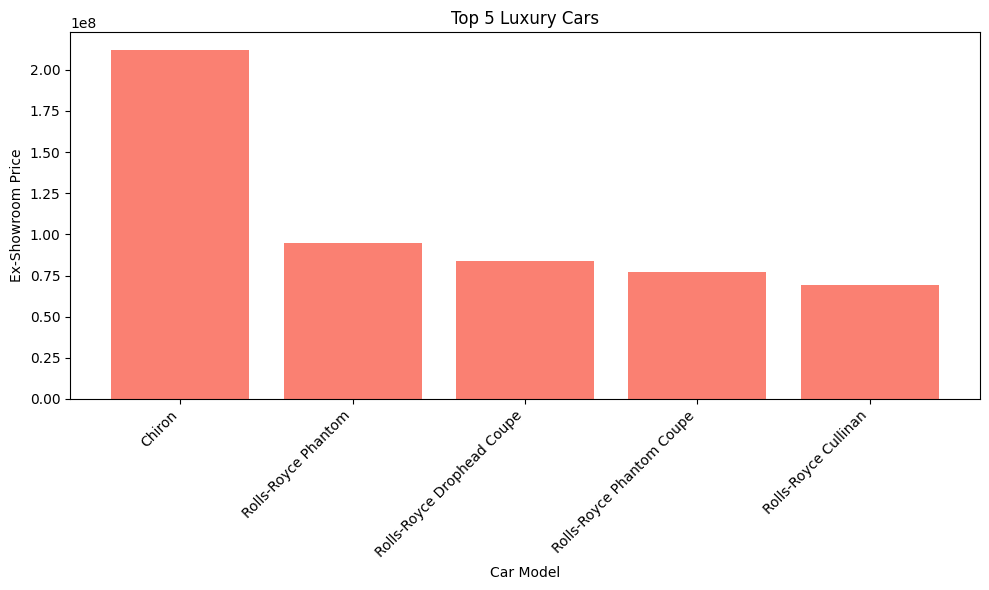

In [ ]:
import matplotlib.pyplot as plt

# Find the top 5 luxury cars
top_5_luxury_cars = data.nlargest(7, 'Ex-Showroom_Price')

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(top_5_luxury_cars['Model'], top_5_luxury_cars['Ex-Showroom_Price'], color='salmon')
plt.xlabel('Car Model')
plt.ylabel('Ex-Showroom Price')
plt.title('Top 5 Luxury Cars')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


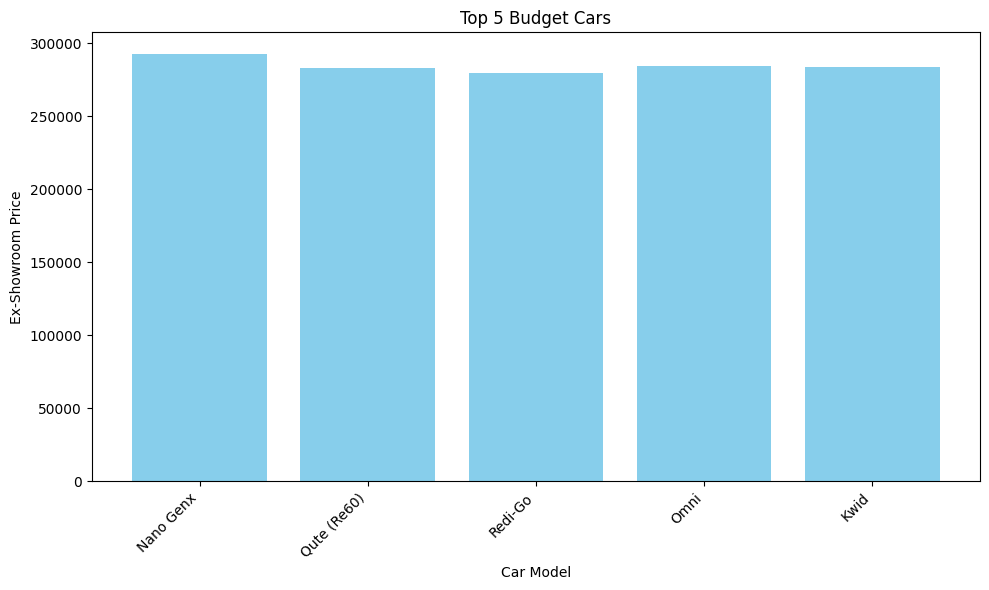

In [ ]:
import matplotlib.pyplot as plt

# Find the top 5 budget cars
top_5_budget_cars = data.nsmallest(9, 'Ex-Showroom_Price')

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(top_5_budget_cars['Model'], top_5_budget_cars['Ex-Showroom_Price'], color='skyblue')
plt.xlabel('Car Model')
plt.ylabel('Ex-Showroom Price')
plt.title('Top 5 Budget Cars')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


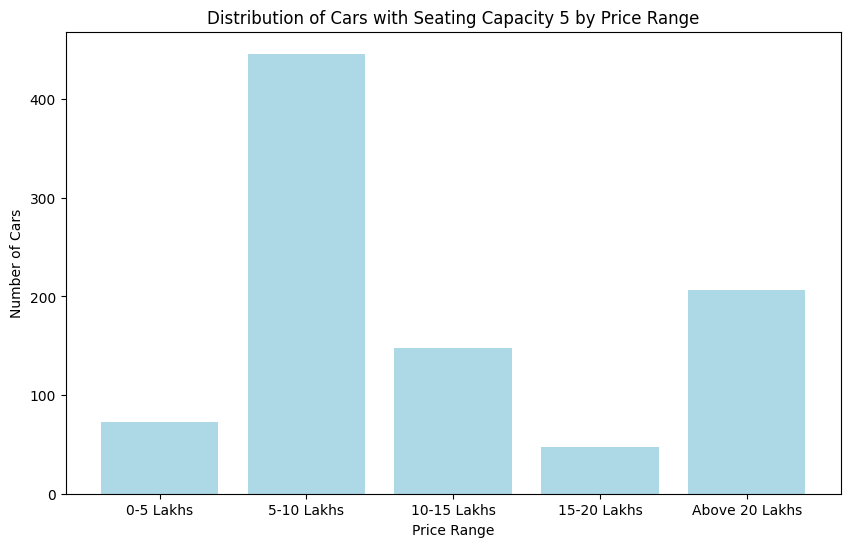

In [ ]:
# Filter the dataset for cars with seating capacity 5
seating_capacity_5 = data[data['Seating_Capacity'] == 5]

# Define the price ranges
price_ranges = [(0, 500000), (500001, 1000000), (1000001, 1500000), (1500001, 2000000), (2000001, float('inf'))]

# Count the number of cars in each price range
car_counts = []
for price_range in price_ranges:
    count = seating_capacity_5[(seating_capacity_5['Ex-Showroom_Price'] >= price_range[0]) &
                               (seating_capacity_5['Ex-Showroom_Price'] < price_range[1])]['Model'].count()
    car_counts.append(count)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.bar(range(len(price_ranges)), car_counts, color='lightblue')
plt.xlabel('Price Range')
plt.ylabel('Number of Cars')
plt.title('Distribution of Cars with Seating Capacity 5 by Price Range')
plt.xticks(range(len(price_ranges)), ['0-5 Lakhs', '5-10 Lakhs', '10-15 Lakhs', '15-20 Lakhs', 'Above 20 Lakhs'])
plt.show()


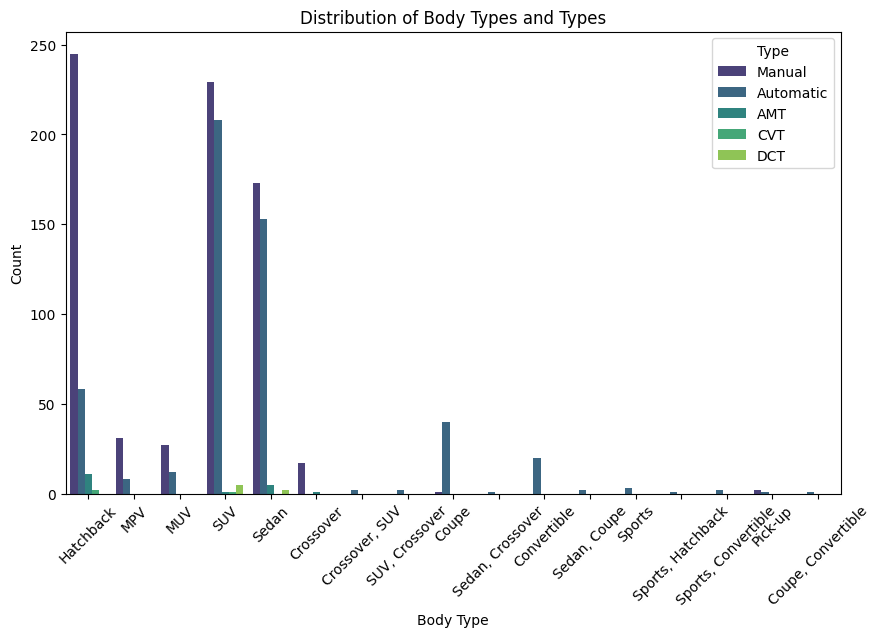

In [ ]:
import seaborn as sns

# Plot the distribution of body types and types
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Body_Type', hue='Type', palette='viridis')
plt.xlabel('Body Type')
plt.ylabel('Count')
plt.title('Distribution of Body Types and Types')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.show()
